# Discrete Time Fourier Transform (DTFT) and FFT for EEG Analysis

This notebook demonstrates Chapter 11 frequency-domain concepts on two signals:
1. A simulated EEG-like signal (known sine components + noise)
2. A real preprocessed EEG segment exported from preprocessing.ipynb

We will:
- Implement a manual DTFT using complex exponentials (Euler's formula)
- Compute the same transform with NumPy FFT
- Verify DTFT and FFT equivalence
- Reconstruct the signal with IFFT and quantify reconstruction error
- Plot correctly scaled one-sided amplitude spectra up to Nyquist

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

np.random.seed(7)

def manual_dtft(x: np.ndarray) -> np.ndarray:
    """Compute DTFT/DFT coefficients manually via dot products with e^{-i2pi kn/N}."""
    x = np.asarray(x, dtype=float)
    N = len(x)
    X = np.zeros(N, dtype=complex)
    n = np.arange(N)

    for k in range(N):
        complex_sine = np.exp(-1j * 2 * np.pi * k * n / N)
        X[k] = np.sum(x * complex_sine)

    return X

def one_sided_amplitude(X: np.ndarray, N: int) -> np.ndarray:
    """Return correctly scaled one-sided amplitude spectrum (DC..Nyquist)."""
    amp = np.abs(X) / N
    n_unique = N // 2 + 1
    amp_one = amp[:n_unique].copy()

    # Double non-DC and non-Nyquist bins for one-sided representation.
    if N % 2 == 0:
        amp_one[1:-1] *= 2
    else:
        amp_one[1:] *= 2

    return amp_one

def analyze_signal(x: np.ndarray, fs: float, label: str):
    N = len(x)
    t = np.arange(N) / fs
    freqs = np.arange(N // 2 + 1) * fs / N

    X_manual = manual_dtft(x)
    X_fft = np.fft.fft(x)
    max_coeff_diff = np.max(np.abs(X_manual - X_fft))

    x_ifft = np.fft.ifft(X_fft)
    max_recon_error = np.max(np.abs(x - np.real(x_ifft)))

    amp_manual = one_sided_amplitude(X_manual, N)
    amp_fft = one_sided_amplitude(X_fft, N)
    max_amp_diff = np.max(np.abs(amp_manual - amp_fft))

    print(f"=== {label} ===")
    print(f"N = {N}, fs = {fs:.2f} Hz, Nyquist = {fs/2:.2f} Hz")
    print(f"DC component (manual) = {X_manual[0]:.6f}")
    print(f"Max |DTFT - FFT| = {max_coeff_diff:.3e}")
    print(f"Max one-sided amplitude difference = {max_amp_diff:.3e}")
    print(f"Max IFFT reconstruction error = {max_recon_error:.3e}")
    print()

    return {
        "t": t,
        "freqs": freqs,
        "X_manual": X_manual,
        "X_fft": X_fft,
        "x_ifft": x_ifft,
        "amp_manual": amp_manual,
        "amp_fft": amp_fft,
        "max_coeff_diff": max_coeff_diff,
        "max_recon_error": max_recon_error,
    }

## Part A: Simulated EEG-Like Signal (1 second at 1000 Hz)

Theory mapping:
- Signal model uses sums of sinusoids: A sin(2 pi f t + theta)
- DTFT computes dot products with complex waves e^{-i2 pi kn/N}
- k = 0 is the DC component (mean offset)
- Unique positive-frequency bins are N/2 + 1 (Nyquist included)

In [2]:
# Generate 1 second of data at 1000 Hz
fs_sim = 1000
duration_sim = 1.0
N_sim = int(fs_sim * duration_sim)
t_sim = np.arange(N_sim) / fs_sim

# Ground-truth sine components (Hz and amplitudes in arbitrary units/uV-like units)
f1, a1 = 7, 2.5
f2, a2 = 15, 1.2
f3, a3 = 30, 0.8

x_sim_clean = (
    a1 * np.sin(2 * np.pi * f1 * t_sim + 0.10)
    + a2 * np.sin(2 * np.pi * f2 * t_sim + 0.55)
    + a3 * np.sin(2 * np.pi * f3 * t_sim + 1.10)
)
noise = 0.6 * np.random.randn(N_sim)
x_sim = x_sim_clean + noise

sim_result = analyze_signal(x_sim, fs_sim, "Simulated EEG-like signal")

=== Simulated EEG-like signal ===
N = 1000, fs = 1000.00 Hz, Nyquist = 500.00 Hz
DC component (manual) = -17.085016+0.000000j
Max |DTFT - FFT| = 1.885e-10
Max one-sided amplitude difference = 3.543e-14
Max IFFT reconstruction error = 2.220e-15



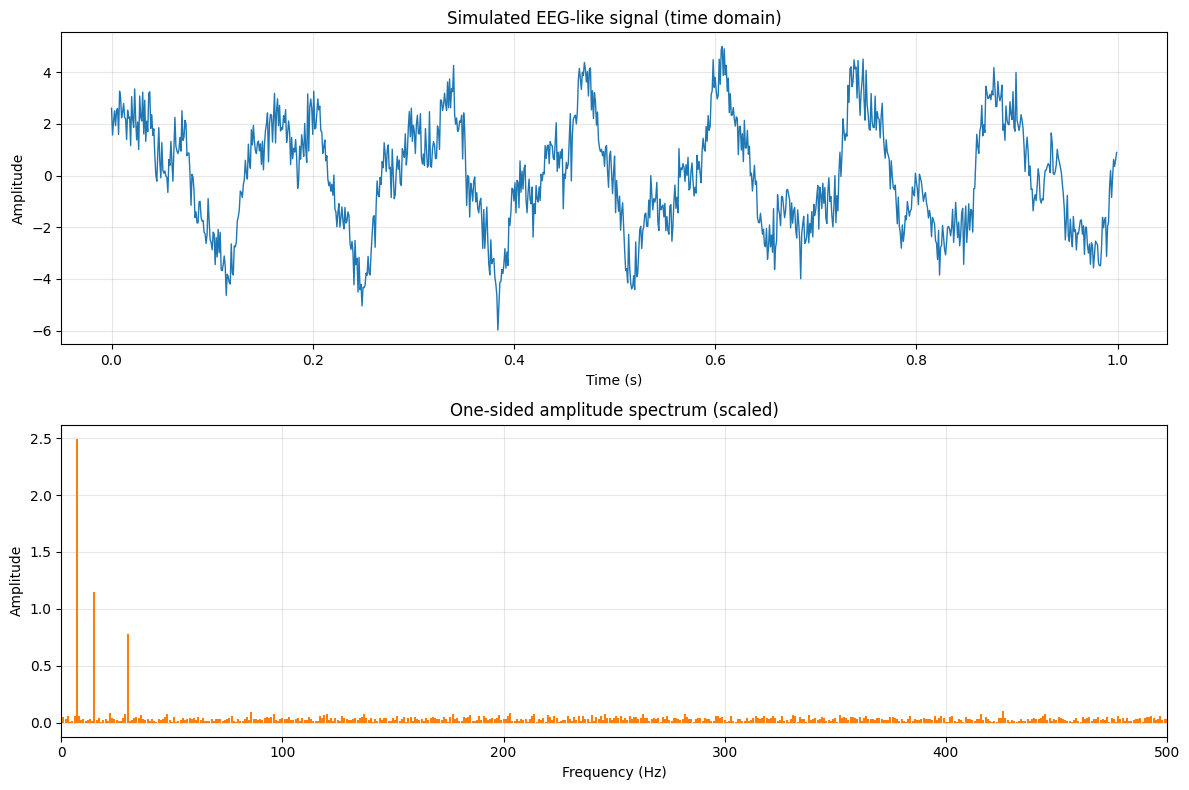

Top spectral peaks (simulated signal):
  f =   7.00 Hz, amp = 2.494
  f =  15.00 Hz, amp = 1.148
  f =  30.00 Hz, amp = 0.781
  f = 426.00 Hz, amp = 0.100
  f =  86.00 Hz, amp = 0.095
  f = 203.00 Hz, amp = 0.088
  f =  22.00 Hz, amp = 0.084
  f = 137.00 Hz, amp = 0.078


In [3]:
# Visualization for simulated signal
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(sim_result["t"], x_sim, color="tab:blue", linewidth=1.0)
axes[0].set_title("Simulated EEG-like signal (time domain)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].grid(alpha=0.3)

axes[1].stem(
    sim_result["freqs"],
    sim_result["amp_fft"],
    basefmt=" ",
    linefmt="tab:orange",
    markerfmt=" ",
)
axes[1].set_xlim(0, fs_sim / 2)
axes[1].set_title("One-sided amplitude spectrum (scaled)")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Amplitude")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Show top peaks
peak_idx = np.argsort(sim_result["amp_fft"])[-8:][::-1]
print("Top spectral peaks (simulated signal):")
for idx in peak_idx:
    print(f"  f = {sim_result['freqs'][idx]:6.2f} Hz, amp = {sim_result['amp_fft'][idx]:.3f}")

## Part B: Preprocessed EEG Segment from preprocessing.ipynb

We load exported preprocessed epochs and extract a 1-second segment to keep manual DTFT computationally feasible.

Notes:
- Manual DTFT has O(N^2) complexity, so very long EEG segments are expensive.
- Using a 1-second segment still demonstrates DC, Nyquist, and spectral peaks clearly.
- The same DTFT/FFT equivalence and IFFT reconstruction checks are performed.

In [4]:
# Load preprocessed data exported in preprocessing.ipynb
preprocessed_dir = Path("../data/preprocessed")
epochs_path = preprocessed_dir / "epochs_rereferenced.npy"
meta_path = preprocessed_dir / "preprocessing_metadata.npz"

if not epochs_path.exists() or not meta_path.exists():
    raise FileNotFoundError(
        "Missing exported files. Run the export step in preprocessing.ipynb first."
    )

epochs_reref = np.load(epochs_path)
meta = np.load(meta_path, allow_pickle=True)

fs_real = float(meta["sampling_rate"])
trial_idx = 0
channel_idx = 0
segment_seconds = 1.0
segment_len = int(fs_real * segment_seconds)

if epochs_reref.shape[2] < segment_len:
    raise ValueError("Epoch is shorter than 1 second. Cannot extract segment.")

x_real = epochs_reref[trial_idx, channel_idx, :segment_len]
x_real = x_real - np.mean(x_real)  # remove residual DC for cleaner display

print("Loaded preprocessed EEG segment:")
print(f"  epochs shape = {epochs_reref.shape}")
print(f"  fs = {fs_real:.2f} Hz")
print(f"  using trial {trial_idx}, channel {channel_idx}, first {segment_seconds} s")

real_result = analyze_signal(x_real, fs_real, "Preprocessed EEG segment")

Loaded preprocessed EEG segment:
  epochs shape = (1, 21, 220000)
  fs = 200.00 Hz
  using trial 0, channel 0, first 1.0 s
=== Preprocessed EEG segment ===
N = 200, fs = 200.00 Hz, Nyquist = 100.00 Hz
DC component (manual) = 0.000000+0.000000j
Max |DTFT - FFT| = 8.210e-11
Max one-sided amplitude difference = 1.053e-13
Max IFFT reconstruction error = 2.132e-14



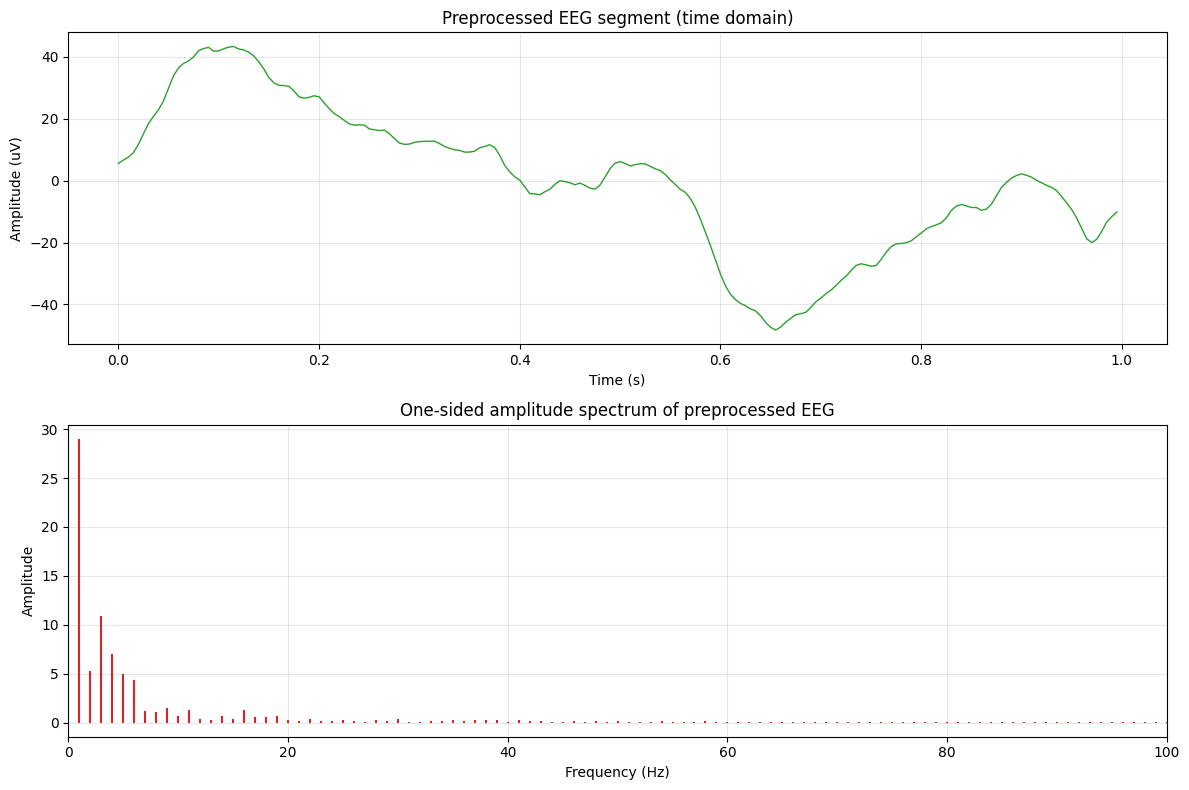

Top spectral peaks (preprocessed EEG segment):
  f =   1.00 Hz, amp = 28.987
  f =   3.00 Hz, amp = 10.906
  f =   4.00 Hz, amp = 6.967
  f =   2.00 Hz, amp = 5.219
  f =   5.00 Hz, amp = 4.925
  f =   6.00 Hz, amp = 4.330
  f =   9.00 Hz, amp = 1.526
  f =  16.00 Hz, amp = 1.298


In [5]:
# Visualization for preprocessed EEG segment
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

time_real = np.arange(len(x_real)) / fs_real
axes[0].plot(time_real, x_real, color="tab:green", linewidth=1.0)
axes[0].set_title("Preprocessed EEG segment (time domain)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude (uV)")
axes[0].grid(alpha=0.3)

axes[1].stem(
    real_result["freqs"],
    real_result["amp_fft"],
    basefmt=" ",
    linefmt="tab:red",
    markerfmt=" ",
)
axes[1].set_xlim(0, fs_real / 2)
axes[1].set_title("One-sided amplitude spectrum of preprocessed EEG")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Amplitude")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

peak_idx_real = np.argsort(real_result["amp_fft"])[-8:][::-1]
print("Top spectral peaks (preprocessed EEG segment):")
for idx in peak_idx_real:
    print(f"  f = {real_result['freqs'][idx]:6.2f} Hz, amp = {real_result['amp_fft'][idx]:.3f}")

## Line-by-Line Concept Walkthrough (Chapter 11 Mapping)

1. `manual_dtft` function
- `N = len(x)` sets the number of samples and therefore frequency-bin spacing $\Delta f = f_s/N$.
- `for k in range(N)` loops over discrete frequencies (the DTFT/DFT frequency bins).
- `np.exp(-1j * 2 * np.pi * k * n / N)` is Euler's formula in computational form, creating a complex sine wave basis for each $k$.
- `X[k] = np.sum(x * complex_sine)` is the dot product: it measures how strongly the signal matches that frequency.
- `k=0` gives `exp(0)=1`, so `X[0]` is the DC component (sum/mean-related offset).

2. `one_sided_amplitude` function
- `np.abs(X)/N` converts complex coefficients to amplitude and normalizes by sample count.
- `N//2 + 1` keeps only unique positive frequencies from 0 Hz to Nyquist.
- Doubling non-DC/non-Nyquist bins preserves total energy in one-sided form.
- This scaling makes spectral peaks approximately match sine-wave amplitudes in time domain.

3. `analyze_signal` function
- Computes manual DTFT and NumPy FFT on the same signal.
- `max |DTFT - FFT|` verifies mathematical equivalence (differences should be near machine precision).
- `ifft(fft(x))` reconstructs the original signal, confirming no information loss in Fourier coefficients.
- Reconstruction error near zero validates inverse-transform correctness.

4. Simulated EEG section
- Signal is built as sum of 7, 15, and 30 Hz sinusoids plus random noise.
- This models the principle that complex signals are mixtures of simpler waves.
- Spectrum peaks should appear near those component frequencies.

5. Preprocessed EEG section
- Loads exported data from preprocessing workflow, ensuring realistic EEG context.
- A 1-second segment is used so manual DTFT remains tractable ($O(N^2)$).
- Same DTFT/FFT/IFFT checks are run to confirm theory holds on real data too.

6. Nyquist and stationarity notes
- Nyquist frequency is $f_s/2$, the highest resolvable frequency without aliasing.
- FFT here assumes segment-level stationarity (frequency content stable within analyzed window).
- EEG is often nonstationary over longer periods, motivating time-localized methods (STFT/wavelets).

7. Convolution theorem relevance
- In practice, FFT is also used for fast filtering because convolution in time equals multiplication in frequency.
- This is a major reason FFT is central to EEG preprocessing and analysis pipelines.

## Part C: Stationarity Example (1-Second Window vs Full EEG Segment)

A stationary signal should have similar frequency content over time. EEG is often nonstationary, so a short window can look very different from a long segment average.

In this example we compare:
- A 1-second EEG window (`x_real`)
- A full trial segment from the same channel

If the spectra are very different, that is evidence against strict stationarity.

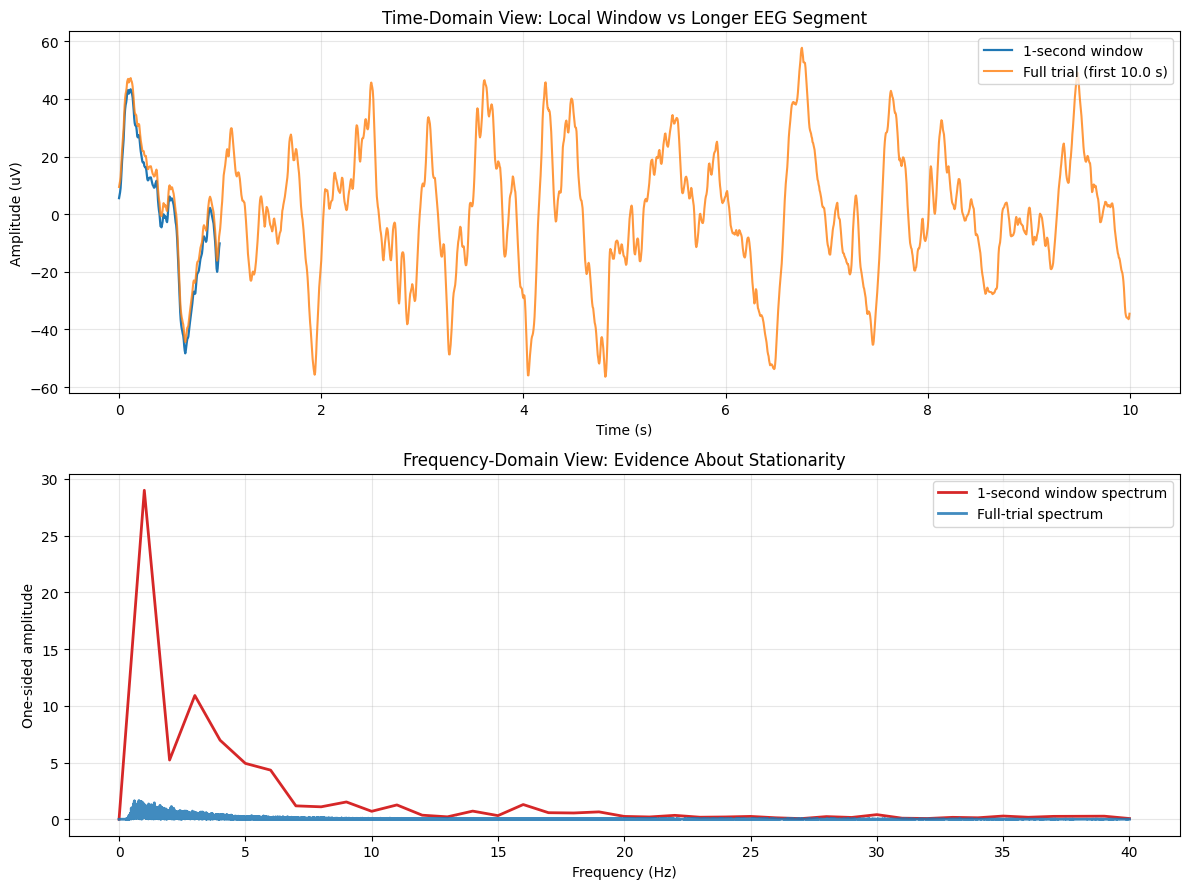

Stationarity comparison metrics:
  Relative L2 spectral difference (1 s vs full): 33.812
  Low/High bandpower ratio (1-8 Hz / 8-30 Hz), 1 s window: 110.227
  Low/High bandpower ratio (1-8 Hz / 8-30 Hz), full trial: 44.740

Interpretation:
  If these metrics differ substantially, the EEG is not strictly stationary across the trial.


In [6]:
# Compare stationarity: 1-second window vs full EEG trial segment
x_full = epochs_reref[trial_idx, channel_idx, :]
x_full = x_full - np.mean(x_full)

N_full = len(x_full)
freqs_full = np.arange(N_full // 2 + 1) * fs_real / N_full
X_full = np.fft.fft(x_full)
amp_full = one_sided_amplitude(X_full, N_full)

# Use same frequency range as the 1-second example for visual comparison
fmax_plot = 40
idx_1s = real_result["freqs"] <= fmax_plot
idx_full = freqs_full <= fmax_plot

# Interpolate full-segment spectrum onto 1-second frequency grid for a simple difference metric
amp_full_interp = np.interp(real_result["freqs"], freqs_full, amp_full)
l2_rel_diff = np.linalg.norm(real_result["amp_fft"] - amp_full_interp) / np.linalg.norm(amp_full_interp)

# Bandpower ratio example: low-frequency dominance can shift across windows
def bandpower(freqs, amp, f_lo, f_hi):
    mask = (freqs >= f_lo) & (freqs <= f_hi)
    return np.sum(amp[mask] ** 2)

bp_1s_low = bandpower(real_result["freqs"], real_result["amp_fft"], 1, 8)
bp_1s_high = bandpower(real_result["freqs"], real_result["amp_fft"], 8, 30)
bp_full_low = bandpower(freqs_full, amp_full, 1, 8)
bp_full_high = bandpower(freqs_full, amp_full, 8, 30)

ratio_1s = bp_1s_low / (bp_1s_high + 1e-12)
ratio_full = bp_full_low / (bp_full_high + 1e-12)

fig, axes = plt.subplots(2, 1, figsize=(12, 9))

# Time-domain comparison (1 s vs first 10 s of full trial)
plot_seconds = min(10.0, N_full / fs_real)
plot_len = int(plot_seconds * fs_real)
time_1s = np.arange(len(x_real)) / fs_real
time_full = np.arange(plot_len) / fs_real

axes[0].plot(time_1s, x_real, label="1-second window", linewidth=1.6)
axes[0].plot(time_full, x_full[:plot_len], label=f"Full trial (first {plot_seconds:.1f} s)", alpha=0.8)
axes[0].set_title("Time-Domain View: Local Window vs Longer EEG Segment")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude (uV)")
axes[0].grid(alpha=0.3)
axes[0].legend(loc="upper right")

# Frequency-domain comparison
axes[1].plot(
    real_result["freqs"][idx_1s],
    real_result["amp_fft"][idx_1s],
    label="1-second window spectrum",
    linewidth=2,
    color="tab:red",
)
axes[1].plot(
    freqs_full[idx_full],
    amp_full[idx_full],
    label="Full-trial spectrum",
    linewidth=2,
    color="tab:blue",
    alpha=0.85,
)
axes[1].set_title("Frequency-Domain View: Evidence About Stationarity")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("One-sided amplitude")
axes[1].grid(alpha=0.3)
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

print("Stationarity comparison metrics:")
print(f"  Relative L2 spectral difference (1 s vs full): {l2_rel_diff:.3f}")
print(f"  Low/High bandpower ratio (1-8 Hz / 8-30 Hz), 1 s window: {ratio_1s:.3f}")
print(f"  Low/High bandpower ratio (1-8 Hz / 8-30 Hz), full trial: {ratio_full:.3f}")
print()
print("Interpretation:")
print("  If these metrics differ substantially, the EEG is not strictly stationary across the trial.")